# kin_02 — Tongue latency analysis

How does tongue movement latency vary across cue-response movement ordinal (k=1, 2, 3, 4),
and does that ordinal effect decompose into a first-movement latency plus a per-movement
interval?

**Pipeline:**
1. Load `all_tongue_movements` parquet
2. Filter to cue-response movements with valid latency
3. Latency distributions by ordinal k
4. Log-normality test for k=1 (first cue-response movement)
5. Session-level latency summaries
6. Cross-ordinal latency correlation: does k=1 latency predict k=2?
7. Δt estimate and RT + IMI de-shift: RT ≈ RT₁ + (k−1)·Δt
8. KS tests: does the de-shifted collapse onto k=1 hold?
9. Noise propagation across k, with bootstrap CI and the cross-session population version
10. Single-session illustration: example trial and raster figures

## 1. Setup

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [2]:
if Path("/root/capsule").exists():
    ENV       = "codeocean"
    SCRATCH   = Path("/root/capsule/scratch")
    FOR_LOCAL = SCRATCH / "for_local"
else:
    ENV       = "local"
    FOR_LOCAL = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local")
    SCRATCH   = FOR_LOCAL.parent

FIG_DIR  = SCRATCH / "figures" / "kin_02_latency"
SAVE_FIG = False
print(f"ENV={ENV}")

ENV=local


## 2. Load data

In [3]:
if ENV == "codeocean":
    movements_path = SCRATCH / "all_tongue_movements_04022026" / "all_tongue_movements_04022026.parquet"
else:
    movements_path = FOR_LOCAL / "all_tongue_movements_04022026.parquet"

all_tongue_movements = pd.read_parquet(movements_path)
print("Shape:", all_tongue_movements.shape)
print("Sessions:", all_tongue_movements["session"].nunique())

Shape: (246359, 49)
Sessions: 44


## 3. Filter to cue-response movements

In [4]:
from scipy import stats as scipy_stats

# All movements belonging to a trial with a known cue-response ordinal and a valid
# latency (every movement in the trial, not just the cue-response one).
movements_valid = (
    all_tongue_movements
    .dropna(subset=["cue_response_movement_number", "movement_latency_from_go"])
    .query("movement_latency_from_go > 0.02 and movement_latency_from_go < 2.0")
    .copy()
)
movements_valid["k"] = movements_valid["cue_response_movement_number"].astype(int)

# The cue-response movement itself: one row per trial. cue_response_movement_number
# is a trial-level constant, so filtering on it alone (without also requiring
# movement_number_in_trial == k) would keep every movement in a k-labeled trial, not
# just the k-th one.
df = movements_valid[
    movements_valid["movement_number_in_trial"] == movements_valid["cue_response_movement_number"]
].copy()
print(df["k"].value_counts().sort_index())

k
1    6958
2    5515
3    1247
4     291
5      67
6      15
Name: count, dtype: int64


## 4. Latency distributions by ordinal

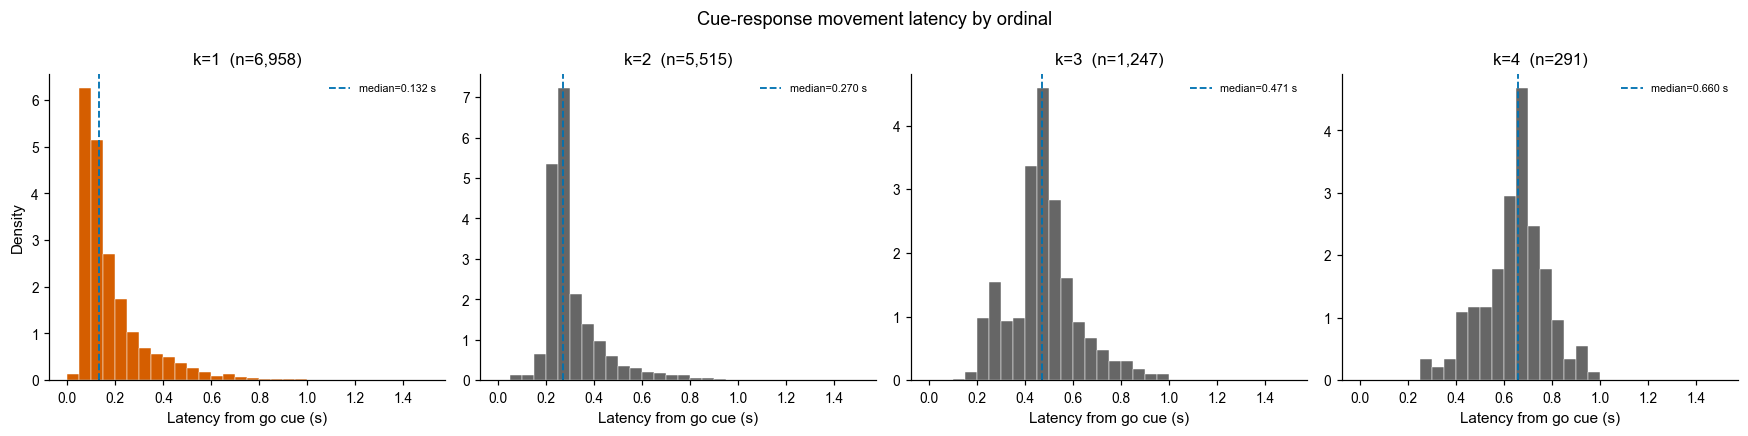

In [5]:
# Latency distributions by cue-response movement ordinal (k=1..4)
MAX_K = 4
fig, axes = plt.subplots(1, MAX_K, figsize=(4 * MAX_K, 4), sharey=False)
bins = np.arange(0, 1.55, 0.05)

for k, ax in zip(range(1, MAX_K + 1), axes):
    sub = df[df["k"] == k]["movement_latency_from_go"].to_numpy()
    sub = sub[np.isfinite(sub)]
    color = PALETTE["pos"] if k == 1 else PALETTE["neutral"]
    ax.hist(sub, bins=bins, color=color, edgecolor="white", linewidth=0.3, density=True)
    ax.axvline(np.median(sub), color=PALETTE["neg"], lw=1.2, ls="--",
               label=f"median={np.median(sub):.3f} s")
    ax.set_xlabel("Latency from go cue (s)")
    ax.set_title(f"k={k}  (n={len(sub):,})")
    ax.legend(fontsize=7)
    style_ax(ax)

axes[0].set_ylabel("Density")
fig.suptitle("Cue-response movement latency by ordinal")
plt.tight_layout()
save_fig(fig, "latency_by_ordinal", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Log-normality test for k=1 RT

RT distributions for tongue movement onset are expected to be approximately log-normal.
This cell fits a log-normal distribution and computes normality tests on raw and log RT.

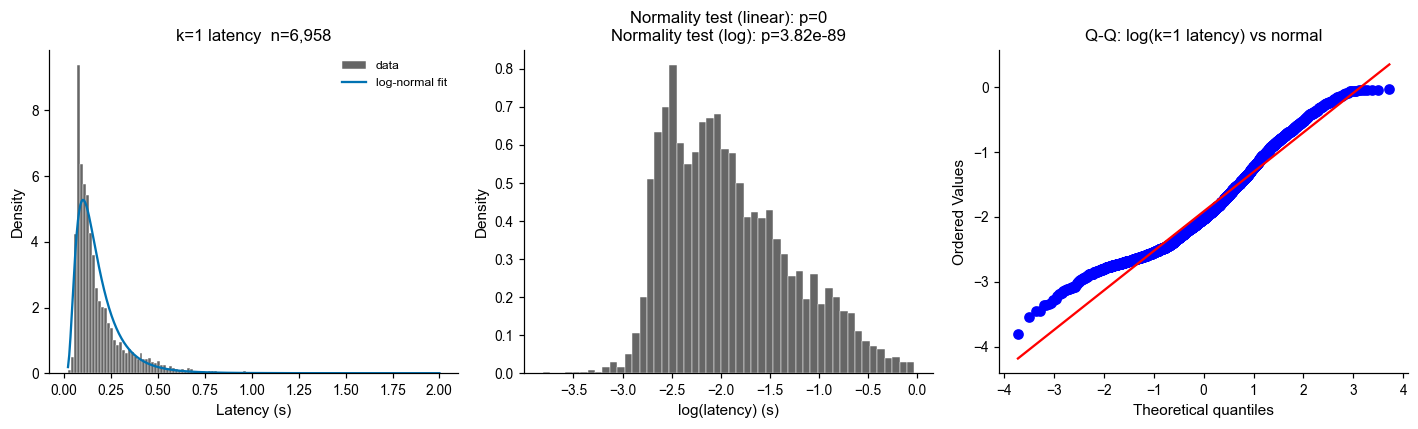

Normality test (raw): stat=3038.570, p=0
Normality test (log): stat=407.181, p=3.818e-89


In [6]:
# Log-normality test for k=1 latency
lat_k1 = df[df["k"] == 1]["movement_latency_from_go"].dropna().to_numpy()
lat_k1 = lat_k1[(lat_k1 > 0.02) & (lat_k1 < 2.0)]

log_lat = np.log(lat_k1)
stat_n,  p_n  = scipy_stats.normaltest(lat_k1)
stat_ln, p_ln = scipy_stats.normaltest(log_lat)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# histogram + log-normal fit
ax = axes[0]
mu_log, sig_log = np.mean(log_lat), np.std(log_lat, ddof=1)
x_range = np.linspace(0.02, 2.0, 300)
pdf_fit = scipy_stats.lognorm(s=sig_log, scale=np.exp(mu_log)).pdf(x_range)
ax.hist(lat_k1, bins=60, density=True, color=PALETTE["neutral"],
        edgecolor="white", linewidth=0.3, label="data")
ax.plot(x_range, pdf_fit, color=PALETTE["neg"], lw=1.5, label="log-normal fit")
ax.set_xlabel("Latency (s)")
ax.set_ylabel("Density")
ax.set_title(f"k=1 latency  n={len(lat_k1):,}")
ax.legend(fontsize=8)
style_ax(ax)

# log-scale histogram
ax = axes[1]
ax.hist(log_lat, bins=50, density=True, color=PALETTE["neutral"],
        edgecolor="white", linewidth=0.3, label="log(latency)")
ax.set_xlabel("log(latency) (s)")
ax.set_ylabel("Density")
ax.set_title(f"Normality test (linear): p={p_n:.3g}\nNormality test (log): p={p_ln:.3g}")
style_ax(ax)

# QQ on log-latency
ax = axes[2]
scipy_stats.probplot(log_lat, dist="norm", plot=ax)
ax.set_title("Q-Q: log(k=1 latency) vs normal")
style_ax(ax)

plt.tight_layout()
save_fig(fig, "k1_lognormal_test", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
print(f"Normality test (raw): stat={stat_n:.3f}, p={p_n:.4g}")
print(f"Normality test (log): stat={stat_ln:.3f}, p={p_ln:.4g}")

## 6. Session-level latency summaries

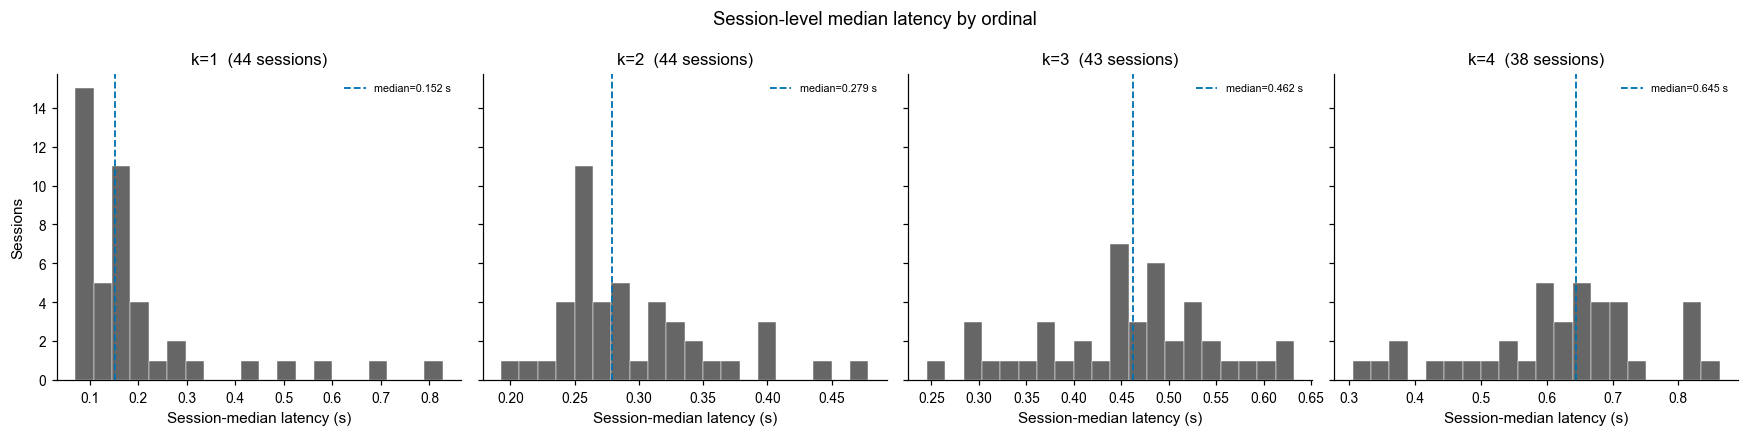

In [7]:
# Session-level latency summary per ordinal
sess_lat = (
    df
    .groupby(["session", "k"])["movement_latency_from_go"]
    .agg(["median", "count"])
    .reset_index()
    .rename(columns={"median":"med_lat","count":"n"})
)

fig, axes = plt.subplots(1, MAX_K, figsize=(4 * MAX_K, 4), sharey=True)
for k, ax in zip(range(1, MAX_K + 1), axes):
    sub = sess_lat[sess_lat["k"] == k]["med_lat"].dropna().to_numpy()
    ax.hist(sub, bins=20, color=PALETTE["neutral"], edgecolor="white", linewidth=0.3)
    ax.axvline(np.median(sub), color=PALETTE["neg"], lw=1.2, ls="--",
               label=f"median={np.median(sub):.3f} s")
    ax.set_xlabel("Session-median latency (s)")
    ax.set_title(f"k={k}  ({len(sub)} sessions)")
    ax.legend(fontsize=7)
    style_ax(ax)
axes[0].set_ylabel("Sessions")
fig.suptitle("Session-level median latency by ordinal")
plt.tight_layout()
save_fig(fig, "session_latency_by_ordinal", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 7. Cross-ordinal latency correlation

Does a session's median k=1 latency predict its median k=2 latency?
If yes, session-level arousal state drives latency variance across ordinals.
Note: k=1 and k=2 movements occur on *different* trials (a trial has only one
cue-response movement), so this is a session-level analysis.

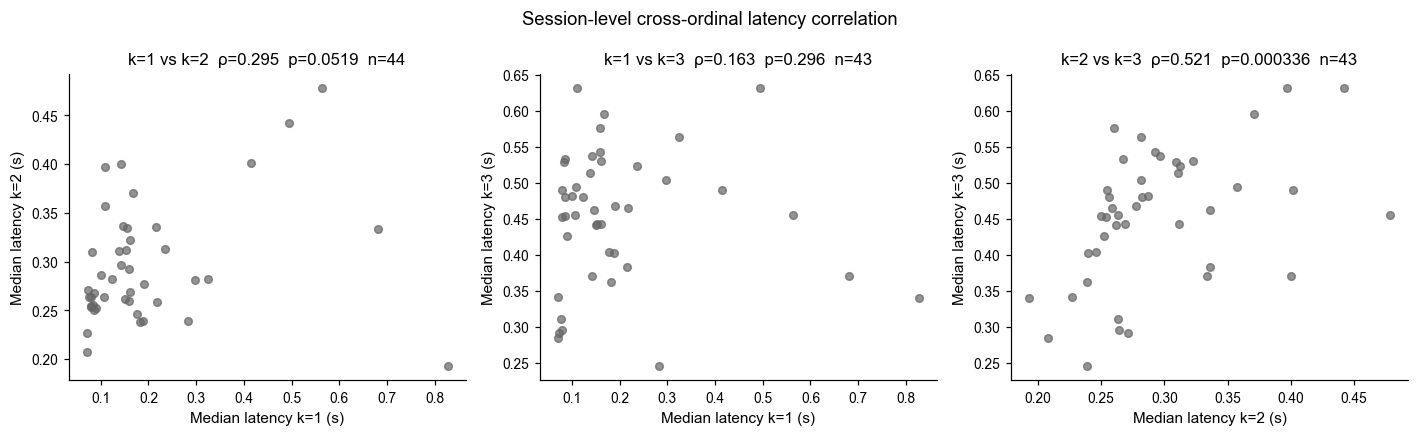

In [8]:
# Session-level: does median k=1 latency predict median k=2 latency?
# k=1 and k=2 movements are on different trials (one cue-response per trial),
# so we compare session-level medians across ordinals.
from scipy.stats import spearmanr

sess_lat = (
    df.groupby(["session", "k"])["movement_latency_from_go"]
    .median()
    .reset_index()
    .rename(columns={"movement_latency_from_go": "med_lat"})
)

sess_wide = sess_lat.pivot(index="session", columns="k", values="med_lat")

# Pairwise session-level rho between k=1 and k=2,3,4
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
compare_ks = [(1, 2), (1, 3), (2, 3)]
for ax, (ka, kb) in zip(axes, compare_ks):
    if ka not in sess_wide.columns or kb not in sess_wide.columns:
        ax.set_visible(False)
        continue
    paired = sess_wide[[ka, kb]].dropna()
    if len(paired) < 5:
        ax.set_title(f"k={ka} vs k={kb}: insufficient sessions")
        continue
    rho, p = spearmanr(paired[ka], paired[kb])
    ax.scatter(paired[ka], paired[kb], s=25, alpha=0.7, color=PALETTE["neutral"])
    ax.set_xlabel(f"Median latency k={ka} (s)")
    ax.set_ylabel(f"Median latency k={kb} (s)")
    ax.set_title(f"k={ka} vs k={kb}  ρ={rho:.3f}  p={p:.3g}  n={len(paired)}")
    style_ax(ax)
fig.suptitle("Session-level cross-ordinal latency correlation")
plt.tight_layout()
save_fig(fig, "session_rho_cross_ordinal", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 8. Δt estimate and RT + IMI de-shift

§4–§7 above use `movement_latency_from_go` — the onset latency of *each* tongue
movement, regardless of whether it produced a lick. This section switches to a
different quantity, `lick_latency`: the lickometer-derived reaction time of the
trial's cue-response lick, conditioned on `cue_response_movement_number` (k). These
are measured on different event streams (video-derived movement onset vs lickometer
contact) and don't have to move in lockstep — the distinction matters because the
two halves of this notebook would otherwise read as contradictory.

The working hypothesis (carried over from `tongue_latency.ipynb`) is that a trial's
lick latency is explained by needing, on average, k movements to reach the
cue-response lick — so RT should decompose as

**RT ≈ RT₁ + (k−1)·Δt**

where RT₁ is the first-movement latency and Δt is the typical interval between
successive movements within a trial. This section estimates Δt from the within-trial
movement stream, then tests whether de-shifting `lick_latency` by (k−1)·Δt collapses
the k=2,3,4 distributions onto k=1.

Estimated Δt (median within-trial IMI, n=9,054): 0.1720 s


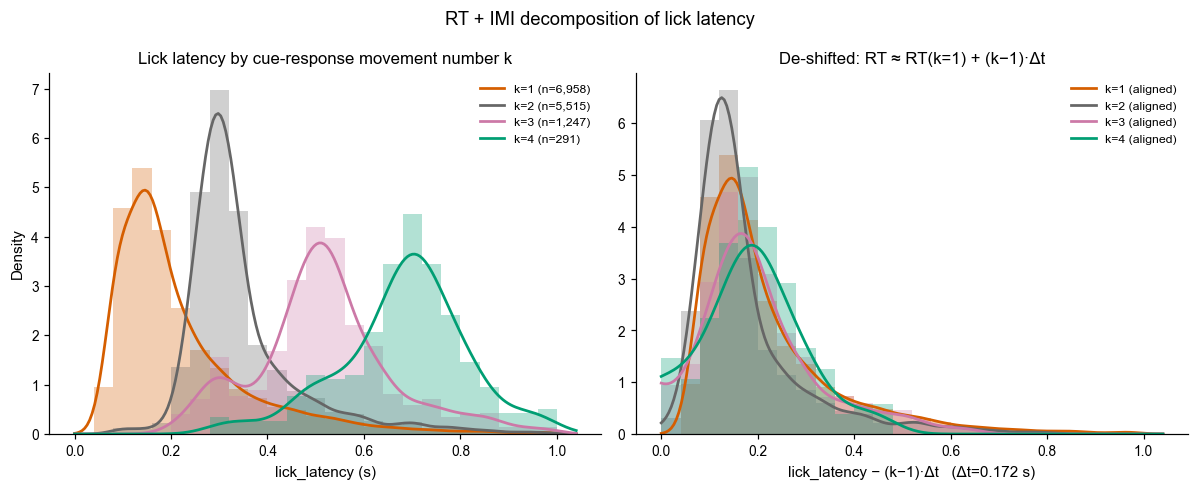

In [9]:
from scipy.stats import gaussian_kde

# --- Δt: median within-trial inter-movement interval ---
# Needs every movement up to and including the trial's cue-response movement (not
# just the cue-response movement itself, which is what §3's `df` now holds), so this
# is built from `movements_valid` rather than `df`.
lat_df = movements_valid[
    movements_valid["movement_number_in_trial"] <= movements_valid["cue_response_movement_number"]
].copy()

mv = (
    lat_df.dropna(subset=["movement_latency_from_go", "movement_number_in_trial"])
    .sort_values(["session", "trial", "movement_number_in_trial"])
)
imi_diffs = (
    mv.groupby(["session", "trial"])["movement_latency_from_go"]
    .apply(lambda x: np.diff(x.to_numpy()))
)
imi_diffs = np.concatenate([d for d in imi_diffs if d.size > 0])
Delta_t = float(np.median(imi_diffs))
print(f"Estimated Δt (median within-trial IMI, n={imi_diffs.size:,}): {Delta_t:.4f} s")

# --- lick_latency by cue-response movement number k, one row per trial ---
per_trial = (
    lat_df.dropna(subset=["lick_latency"])
    .drop_duplicates(["session", "trial"])[["session", "trial", "lick_latency", "k"]]
)
by_k = per_trial.query("k <= @MAX_K").groupby("k")["lick_latency"]
k_colors = {1: PALETTE["pos"], 2: PALETTE["neutral"], 3: PALETTE["accent"], 4: PALETTE["baseline"]}
bins = np.arange(0, 1.05, 0.04)
xs = np.linspace(bins[0], bins[-1], 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
aligned = {}
for k, series in by_k:
    arr = series.to_numpy()
    color = k_colors.get(int(k), PALETTE["neutral"])

    axes[0].hist(arr, bins=bins, density=True, alpha=0.3, color=color)
    axes[0].plot(xs, gaussian_kde(arr)(xs), color=color, lw=1.8, label=f"k={int(k)} (n={arr.size:,})")

    shifted = arr - (int(k) - 1) * Delta_t
    aligned[int(k)] = shifted
    axes[1].hist(shifted, bins=bins, density=True, alpha=0.3, color=color)
    axes[1].plot(xs, gaussian_kde(shifted)(xs), color=color, lw=1.8, label=f"k={int(k)} (aligned)")

axes[0].set(xlabel="lick_latency (s)", ylabel="Density",
            title="Lick latency by cue-response movement number k")
axes[1].set(xlabel=f"lick_latency − (k−1)·Δt   (Δt={Delta_t:.3f} s)",
            title="De-shifted: RT ≈ RT(k=1) + (k−1)·Δt")
for ax in axes:
    ax.legend(fontsize=8)
    style_ax(ax)

fig.suptitle("RT + IMI decomposition of lick latency")
plt.tight_layout()
save_fig(fig, "lick_latency_rt_imi_deshift", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 9. Does the collapse hold? KS tests against k=1

Two-sample KS test of each de-shifted k against the de-shifted k=1 distribution.
A collapse under the RT + IMI model predicts these should be statistically
indistinguishable.

In [10]:
from scipy.stats import ks_2samp

base = aligned.get(1)
ks_rows = []
for k in sorted(aligned):
    if k == 1:
        continue
    stat, p = ks_2samp(aligned[k], base)
    ks_rows.append({"k": k, "ks_stat": stat, "p": p, "n_k": aligned[k].size, "n_k1": base.size})

ks_df = pd.DataFrame(ks_rows)
print("Aligned-shape similarity to k=1 (KS test):")
display(ks_df)

Aligned-shape similarity to k=1 (KS test):


,k,ks_stat,p,n_k,n_k1
0,2,0.186907,2.146122e-94,5515,6958
1,3,0.188340,2.733755e-33,1247,6958
2,4,0.199300,3.373842e-10,291,6958


## 10. Noise propagation across movement number

Does the spread of lick latency grow with k? `std_aligned` is included alongside
`std_raw` for continuity with `tongue_latency.ipynb`, but the two are identical by
construction — de-shifting by a constant `(k−1)·Δt` per k cannot change that k
group's own standard deviation. The de-shift changes where each k's distribution
sits (tested in §9), not how wide it is; SD growth with k is therefore a genuinely
separate observation, estimated here with a bootstrap 95% CI. The panel below is
followed by the population version: cross-session grand mean ± SEM by cue-response
movement number, with session as the sampling unit.

,k,n,std_raw,std_aligned,ci_low,ci_high
0,1,6958,0.144695,0.144695,0.140560,0.149050
1,2,5515,0.120434,0.120434,0.115930,0.125034
2,3,1247,0.142791,0.142791,0.135858,0.149014
3,4,291,0.130636,0.130636,0.117884,0.142243


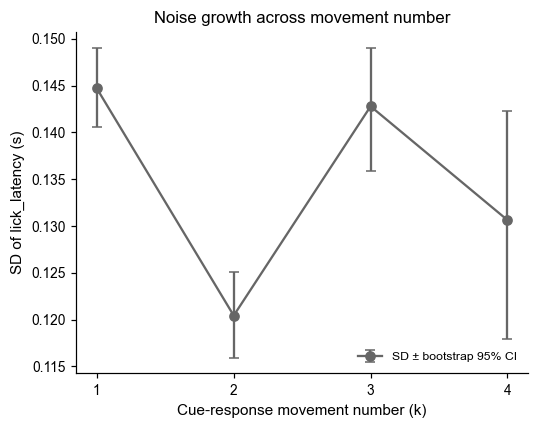

In [11]:
def bootstrap_std_ci(data, n_boot=1000, alpha=0.05, rng=None):
    """Bootstrap a confidence interval for the standard deviation of a sample.

    Parameters
    ----------
    data : array-like
        1-D sample of observations.
    n_boot : int
        Number of bootstrap resamples.
    alpha : float
        Two-sided CI level; 0.05 gives a 95% interval.
    rng : numpy.random.Generator, optional
        Random generator to draw resamples from. A fresh default_rng() is
        used if omitted.

    Returns
    -------
    lo, hi : float
        Lower and upper percentile bounds of the bootstrapped SD. ``(nan, nan)``
        if ``data`` has fewer than 5 observations.
    """
    data = np.asarray(data)
    if data.size < 5:
        return np.nan, np.nan
    rng = rng if rng is not None else np.random.default_rng()
    boot = [np.std(rng.choice(data, data.size, replace=True)) for _ in range(n_boot)]
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


rng = np.random.default_rng(0)
noise_rows = []
for k, series in by_k:
    arr = series.to_numpy()
    lo, hi = bootstrap_std_ci(arr, rng=rng)
    noise_rows.append({
        "k": int(k), "n": arr.size,
        "std_raw": np.std(arr), "std_aligned": np.std(aligned[int(k)]),
        "ci_low": lo, "ci_high": hi,
    })
noise_df = pd.DataFrame(noise_rows).sort_values("k")
display(noise_df)

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(noise_df["k"], noise_df["std_raw"],
            yerr=[noise_df["std_raw"] - noise_df["ci_low"], noise_df["ci_high"] - noise_df["std_raw"]],
            fmt="o-", color=PALETTE["neutral"], capsize=3, label="SD ± bootstrap 95% CI")
ax.set(xlabel="Cue-response movement number (k)", ylabel="SD of lick_latency (s)",
       title="Noise growth across movement number")
ax.set_xticks(noise_df["k"])
ax.legend(fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "lick_latency_sd_by_k_bootstrap", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

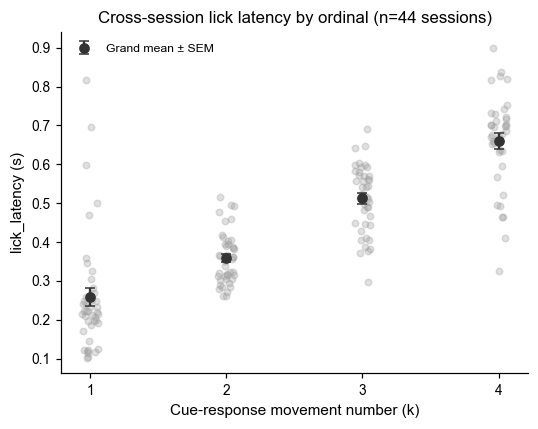

,k,grand_mean,grand_sem,n_sessions
0,1,0.257676,0.022661,44
1,2,0.358417,0.009953,44
2,3,0.512073,0.013043,43
3,4,0.6603,0.019837,38


In [12]:
# Population version of the same claim: grand mean +/- SEM across sessions,
# with session (not trial) as the sampling unit.
per_trial_k = per_trial.query("k >= 1 and k <= @MAX_K")
sess_summary = (
    per_trial_k.groupby(["session", "k"], observed=True)["lick_latency"]
    .agg(mean="mean", n="size")
    .reset_index()
)
grand = (
    sess_summary.groupby("k", observed=True)
    .agg(grand_mean=("mean", "mean"),
         grand_sem=("mean", lambda x: x.std(ddof=1) / np.sqrt(x.size)),
         n_sessions=("session", "nunique"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))
jitter_rng = np.random.default_rng(0)
for sess, sub in sess_summary.groupby("session"):
    x_jitter = sub["k"] + jitter_rng.uniform(-0.06, 0.06, size=len(sub))
    ax.scatter(x_jitter, sub["mean"], color=PALETTE["not_sig"], alpha=0.3, s=18, zorder=1)
ax.errorbar(grand["k"], grand["grand_mean"], yerr=grand["grand_sem"],
            fmt="o", color=PALETTE["all"], markersize=6, elinewidth=1.5, capsize=3,
            zorder=3, label="Grand mean ± SEM")
ax.set(xlabel="Cue-response movement number (k)", ylabel="lick_latency (s)",
       title=f"Cross-session lick latency by ordinal (n={grand['n_sessions'].max()} sessions)")
ax.set_xticks(range(1, MAX_K + 1))
ax.legend(fontsize=8)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "lick_latency_grandmean_by_k", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()
display(grand)

**Open question, not resolved here.** §9's KS tests show the de-shifted distributions
do not fully collapse onto k=1 — a secondary "bump" is visible in the raw k=1 and k=2
distributions in §8. The working hypothesis carried over from `tongue_latency.ipynb`
is that this residual reflects *further* covert preparatory tongue movements not
captured by the cue-response ordinal — i.e. more structure in the movement stream
than the RT + IMI model accounts for. This notebook does not test that; it is the
premise `kin_05_nonlick_movements` takes up directly.

## 11. Single-session illustration: example trial and raster figures

§1–§10 pool across all 44 sessions. This closing section illustrates the same
lick-vs-movement-latency story in one example session,
`behavior_716325_2024-05-31_10-31-14` — the session `tongue_latency.ipynb` itself used
for these figures — via the trial-raster and colored-histogram figures from that
notebook (cells 5, 8, 9, 14).

The single-trial tongue-position trace needs per-frame tongue keypoint positions
(`tongue_kins.parquet`), which are not in the pooled parquet, so that figure is Code
Ocean-only. The rasters and histograms below it use only movement-level columns
already in `all_tongue_movements`, so they run locally on the pooled data restricted
to this one session.

In [13]:
def coerce_bool(series):
    """Coerce an object-dtype True/False/None column to real booleans.

    Plain ``astype(bool)`` on an object column turns any non-empty string
    (including the string "False") into True. This instead treats only
    True/1/"True" as true and everything else, including None, as false.

    Parameters
    ----------
    series : pandas.Series
        Object-dtype column holding True/False/None (or their 1/0/string
        equivalents).

    Returns
    -------
    pandas.Series
        Boolean-dtype series.
    """
    return series.isin([True, 1, "True"])


EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"
EXAMPLE_TRIAL = 0

# A trial-less movement (trial is NaN) isn't part of any raster row; drop it.
sess_df = (
    all_tongue_movements[all_tongue_movements["session"] == EXAMPLE_SESSION]
    .dropna(subset=["trial"])
    .copy()
)
sess_df["cue_response"] = coerce_bool(sess_df["cue_response"])
sess_df["has_lick"] = coerce_bool(sess_df["has_lick"])
sess_df["movement_number_in_trial"] = pd.to_numeric(sess_df["movement_number_in_trial"], errors="coerce")
sess_df["movement_latency_from_go"] = pd.to_numeric(sess_df["movement_latency_from_go"], errors="coerce")
print(f"{EXAMPLE_SESSION}: {sess_df.shape[0]} movements, {sess_df['trial'].nunique()} trials")

behavior_716325_2024-05-31_10-31-14: 7360 movements, 569 trials


**Example trial: tongue position over time (Code Ocean only).** Tongue y-position
across one trial, colored by whether the frame belongs to a lick-associated movement,
with the go cue and the cue-response lick marked. Not executed locally — the schema
below (`tongue_kins.parquet` columns `trial`, `movement_id`, `time_in_session`, `y`)
is assumed from `tongue_latency.ipynb` cell 5 and from `kin_00`'s per-session loading
pattern, and is unverified against the current Code Ocean data asset.

In [14]:
if ENV == "codeocean":
    kins_path = SCRATCH / "session_analysis_mlk" / EXAMPLE_SESSION / "intermediate_data" / "tongue_kins.parquet"
    if kins_path.exists():
        tongue_kins = pd.read_parquet(kins_path)
        trial_kins = tongue_kins[tongue_kins["trial"] == EXAMPLE_TRIAL].copy()
        trial_kins = trial_kins.merge(
            sess_df[["movement_id", "has_lick"]], on="movement_id", how="left"
        )
        trial_kins["has_lick"] = trial_kins["has_lick"].fillna(False)

        gocue_time = sess_df.loc[sess_df["trial"] == EXAMPLE_TRIAL, "goCue_start_time_in_session"].iloc[0]
        trial_kins["time_from_go"] = trial_kins["time_in_session"] - gocue_time

        cue_resp_row = sess_df[(sess_df["trial"] == EXAMPLE_TRIAL) & sess_df["cue_response"]].iloc[0]
        first_lick_from_go = cue_resp_row["lick_time"] - gocue_time

        fig, ax = plt.subplots(figsize=(6, 5))
        for lick_val, color, label in [(True, PALETTE["all"], "Lick-associated"),
                                        (False, PALETTE["neg"], "Non-lick")]:
            sub = trial_kins[trial_kins["has_lick"] == lick_val]
            ax.scatter(sub["time_from_go"], sub["y"], s=15, alpha=0.6, color=color, label=label)
        ax.axvline(first_lick_from_go, color=PALETTE["pos"], ls="--", lw=1.2, label="Cue-response lick")
        ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1.2, label="Go cue")
        ax.set(xlim=(-0.5, 2), xlabel="Time from go cue (s)", ylabel="Tongue y-position (pix)",
               title=f"Tongue position over time (trial {EXAMPLE_TRIAL})")
        ax.legend(fontsize=8, title="Movement type")
        style_ax(ax)
        plt.tight_layout()
        save_fig(fig, "example_trial_tongue_position", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()
    else:
        print(f"[skip] Example trial tongue position: no tongue_kins.parquet found for {EXAMPLE_SESSION}")
else:
    print("[skip] Example trial tongue position: Code Ocean only (needs per-frame tongue_kins.parquet).")

[skip] Example trial tongue position: Code Ocean only (needs per-frame tongue_kins.parquet).


**Raster: movements by type.** Every movement in the example session as a tick at its
`movement_latency_from_go`, one row per trial (trials sorted by cue-response time),
colored by whether it's the cue-response lick, another lick, or a non-lick movement.

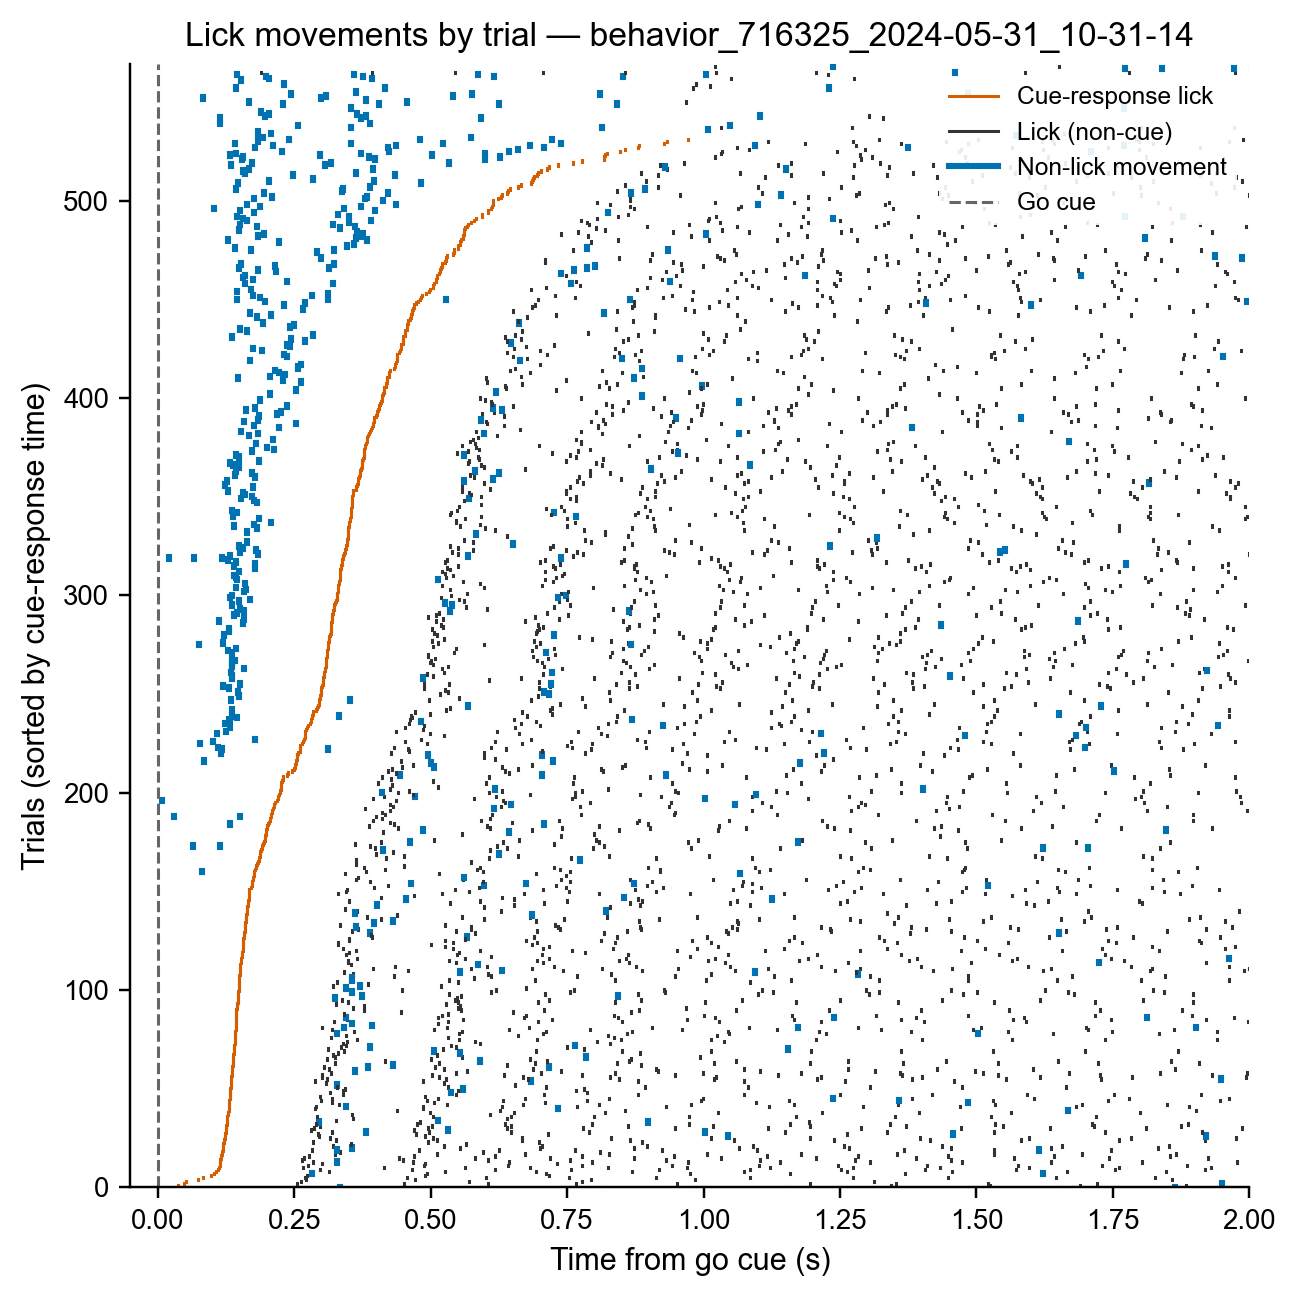

In [15]:
from matplotlib.lines import Line2D

XMIN, XMAX = -0.05, 2.0
LINE_HALFHEIGHT = 0.4

cue_rows = sess_df.loc[sess_df["cue_response"]].copy()
cue_response_by_trial = (
    cue_rows.sort_values(["trial", "movement_number_in_trial"])
    .drop_duplicates("trial", keep="first")[["trial", "movement_latency_from_go"]]
    .rename(columns={"movement_latency_from_go": "cue_rel_time"})
)
raster = sess_df.merge(cue_response_by_trial, on="trial", how="left")

sorted_trials = (
    raster[["trial", "cue_rel_time"]].drop_duplicates()
    .sort_values("cue_rel_time", na_position="last")["trial"].tolist()
)
trial_to_idx = {t: i for i, t in enumerate(sorted_trials)}
raster["trial_idx"] = raster["trial"].map(trial_to_idx)

raster["color"] = np.select(
    [raster["cue_response"], raster["has_lick"]],
    [PALETTE["pos"], PALETTE["all"]],
    default=PALETTE["neg"],
)

# dpi bumped: at the default figure.dpi (110), ~570 trial rows squeezed into ~600
# vertical pixels leaves under 1.2 px/trial, and matplotlib's anti-aliasing drops
# rows unevenly at that density, showing up as spurious horizontal gaps.
fig, ax = plt.subplots(figsize=(6, 6), dpi=220)
valid = raster["movement_latency_from_go"].notna() & raster["trial_idx"].notna()
for row in raster.loc[valid].itertuples(index=False):
    lw = 2 if row.color == PALETTE["neg"] else 1
    ax.plot([row.movement_latency_from_go, row.movement_latency_from_go],
            [row.trial_idx - LINE_HALFHEIGHT, row.trial_idx + LINE_HALFHEIGHT],
            color=row.color, linewidth=lw)

ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1)
ax.set(xlim=(XMIN, XMAX), ylim=(0, len(sorted_trials)),
       xlabel="Time from go cue (s)", ylabel="Trials (sorted by cue-response time)",
       title=f"Lick movements by trial — {EXAMPLE_SESSION}")
legend_elements = [
    Line2D([0], [0], color=PALETTE["pos"], lw=1, label="Cue-response lick"),
    Line2D([0], [0], color=PALETTE["all"], lw=1, label="Lick (non-cue)"),
    Line2D([0], [0], color=PALETTE["neg"], lw=2, label="Non-lick movement"),
    Line2D([0], [0], color=PALETTE["neutral"], lw=1, ls="--", label="Go cue"),
]
# Opaque background: the default frameless legend (plotstyle convention) is
# illegible over a raster this dense.
ax.legend(handles=legend_elements, loc="upper right", fontsize=8,
          frameon=True, facecolor="white", edgecolor="none", framealpha=0.9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "example_session_raster_by_movement_type", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

**Raster: movements by ordinal.** Same layout, trials now sorted by first-movement
time and ticks colored by `movement_number_in_trial` (the cue-response movement
outlined in black), to show where in the movement sequence the response tends to
land.

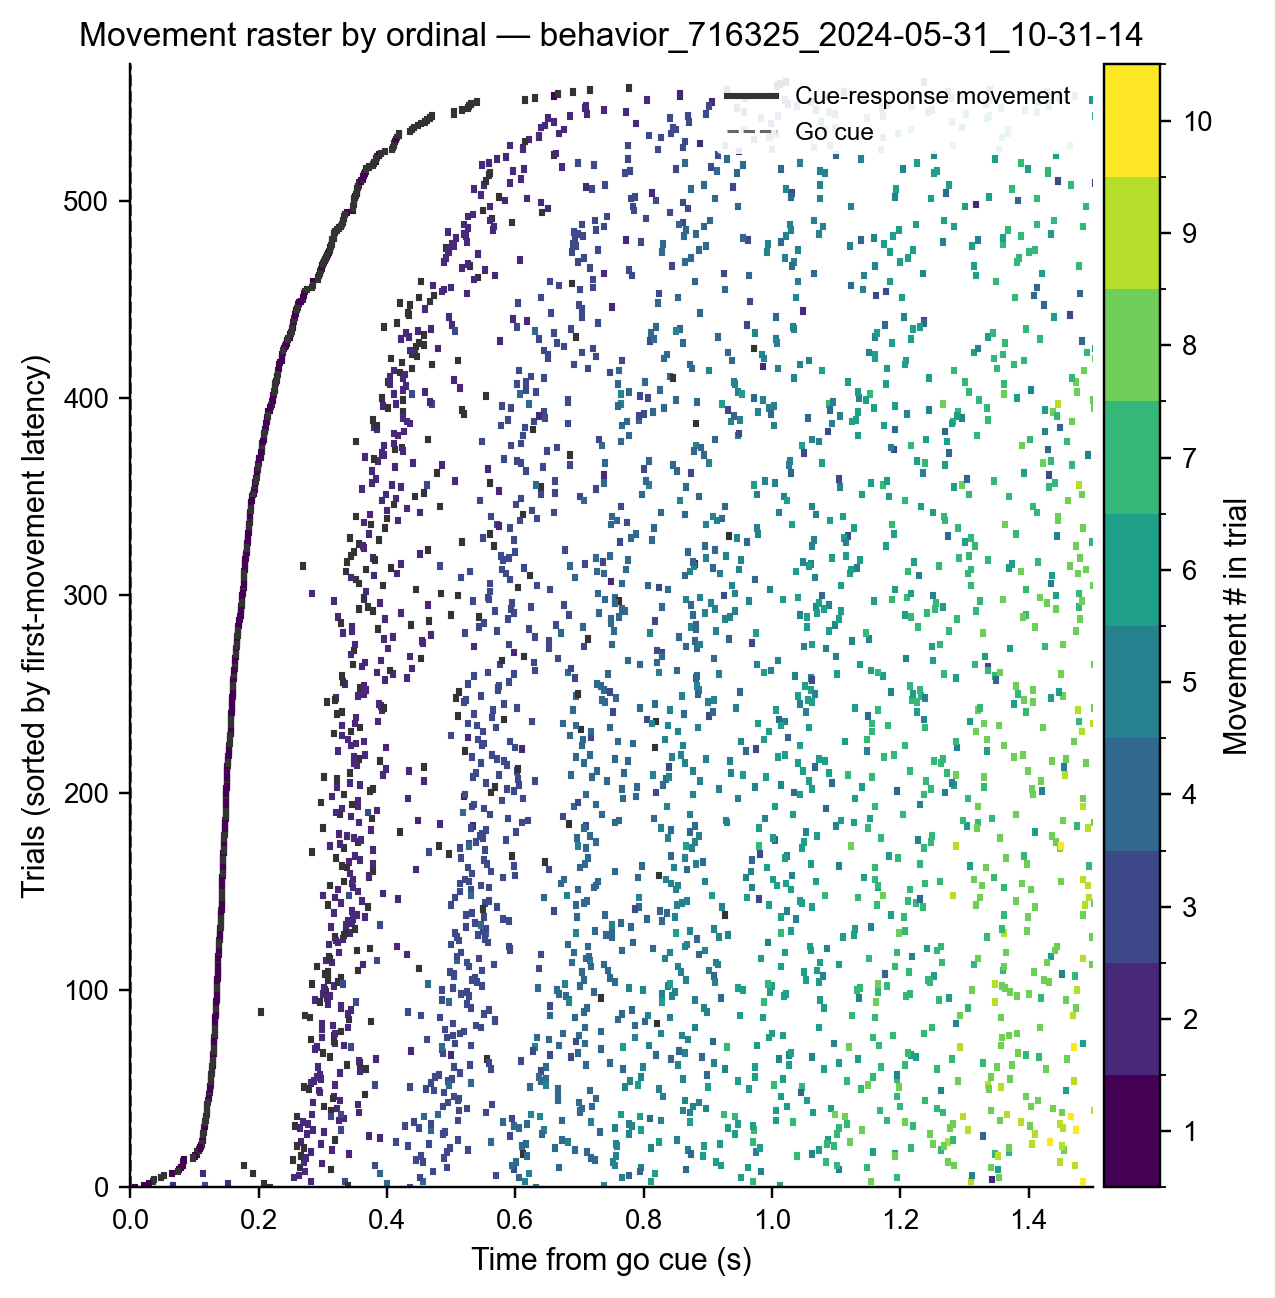

In [16]:
from matplotlib.colors import BoundaryNorm

XMIN2, XMAX2 = 0, 1.5

first_move_by_trial = (
    sess_df.dropna(subset=["movement_latency_from_go"])
    .sort_values(["trial", "movement_number_in_trial"])
    .groupby("trial", as_index=False)["movement_latency_from_go"].first()
    .rename(columns={"movement_latency_from_go": "first_move_time"})
)
raster2 = sess_df.merge(first_move_by_trial, on="trial", how="left")

sorted_trials2 = (
    raster2[["trial", "first_move_time"]].drop_duplicates()
    .sort_values("first_move_time", na_position="last")["trial"].tolist()
)
trial_to_idx2 = {t: i for i, t in enumerate(sorted_trials2)}
raster2["trial_idx"] = raster2["trial"].map(trial_to_idx2)

valid2 = raster2["movement_latency_from_go"].notna() & raster2["trial_idx"].notna()
in_window = valid2 & raster2["movement_latency_from_go"].between(XMIN2, XMAX2, inclusive="both")
k_in_window = raster2.loc[in_window, "movement_number_in_trial"].dropna()
vmin, vmax = int(np.nanmin(k_in_window)), int(np.nanmax(k_in_window))

levels = np.arange(vmin, vmax + 1)
boundaries = np.arange(vmin - 0.5, vmax + 1.5, 1)
cmap = plt.get_cmap("viridis", len(levels))
norm = BoundaryNorm(boundaries, cmap.N)

def color_for_row(row):
    if row["cue_response"]:
        return PALETTE["all"]
    kk = int(np.clip(round(row["movement_number_in_trial"]), vmin, vmax))
    return cmap(norm(kk))

raster2["color"] = raster2.loc[valid2].apply(color_for_row, axis=1)

# dpi bumped: see the note in the previous raster cell — same under-1-px/trial
# aliasing issue at the default figure.dpi.
fig, ax = plt.subplots(figsize=(6, 6), dpi=220)
for row in raster2.loc[valid2].itertuples(index=False):
    ax.plot([row.movement_latency_from_go, row.movement_latency_from_go],
            [row.trial_idx - LINE_HALFHEIGHT, row.trial_idx + LINE_HALFHEIGHT],
            color=row.color, linewidth=2)

ax.axvline(0, color=PALETTE["neutral"], ls="--", lw=1)
ax.set(xlim=(XMIN2, XMAX2), ylim=(0, len(sorted_trials2)),
       xlabel="Time from go cue (s)", ylabel="Trials (sorted by first-movement latency)",
       title=f"Movement raster by ordinal — {EXAMPLE_SESSION}")

mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(mappable, ax=ax, pad=0.01, boundaries=boundaries, ticks=levels, spacing="proportional")
cbar.set_label("Movement # in trial")

legend_elements = [
    Line2D([0], [0], color=PALETTE["all"], lw=2, label="Cue-response movement"),
    Line2D([0], [0], color=PALETTE["neutral"], lw=1, ls="--", label="Go cue"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8,
          frameon=True, facecolor="white", edgecolor="none", framealpha=0.9)
style_ax(ax)
plt.tight_layout()
save_fig(fig, "example_session_raster_by_ordinal", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

**Lick latency vs. movement latency (colored histograms).** Left: lick latency against
the 1st- and 2nd-movement latencies, pooled over all trials in the session. Right:
lick latency split by cue-response movement number k, reusing §8's `k_colors` so the
same k means the same color throughout the notebook.

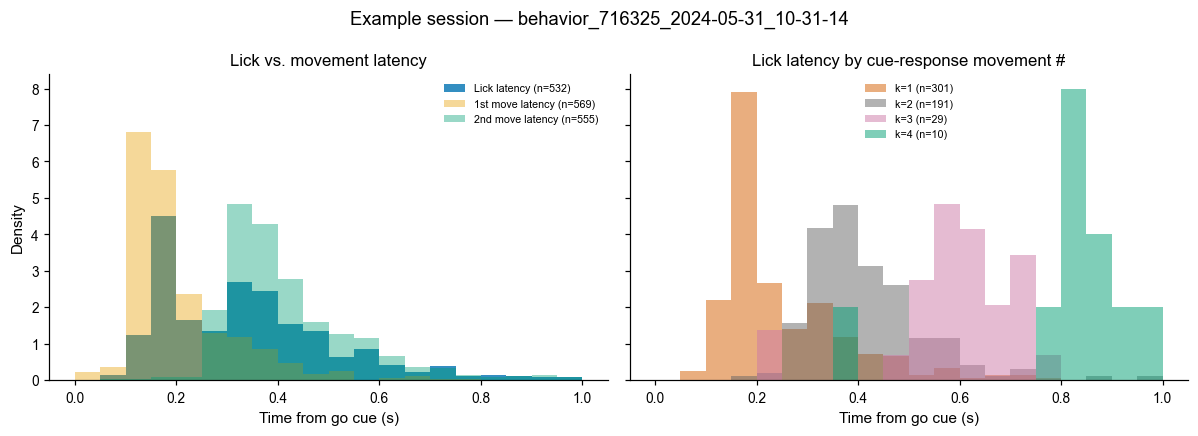

In [17]:
bins2 = np.arange(0, 1.05, 0.05)

lick_lat = sess_df.drop_duplicates("trial")["lick_latency"].dropna()
moves = (
    sess_df[["trial", "movement_number_in_trial", "movement_latency_from_go"]]
    .dropna(subset=["movement_latency_from_go"])
    .sort_values(["trial", "movement_number_in_trial"])
)
first_move = moves.groupby("trial").nth(0)["movement_latency_from_go"].dropna()
second_move = moves.groupby("trial").nth(1)["movement_latency_from_go"].dropna()

per_trial_sess = (
    sess_df.dropna(subset=["lick_latency", "cue_response_movement_number"])
    .drop_duplicates("trial")
)
lick_by_k_sess = (
    per_trial_sess.query("cue_response_movement_number <= @MAX_K")
    .groupby("cue_response_movement_number")["lick_latency"]
    .apply(list).to_dict()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

ax = axes[0]
ax.hist(lick_lat, bins=bins2, density=True, alpha=0.8, color=PALETTE["neg"], label=f"Lick latency (n={len(lick_lat)})")
ax.hist(first_move, bins=bins2, density=True, alpha=0.4, color=PALETTE["sig"], label=f"1st move latency (n={len(first_move)})")
ax.hist(second_move, bins=bins2, density=True, alpha=0.4, color=PALETTE["baseline"], label=f"2nd move latency (n={len(second_move)})")
ax.set(title="Lick vs. movement latency", xlabel="Time from go cue (s)", ylabel="Density")
ax.legend(fontsize=7)
style_ax(ax)

ax = axes[1]
for k in sorted(lick_by_k_sess):
    latencies = lick_by_k_sess[k]
    color = k_colors.get(int(k), PALETTE["neutral"])
    ax.hist(latencies, bins=bins2, density=True, alpha=0.5, color=color,
            label=f"k={int(k)} (n={len(latencies)})")
ax.set(title="Lick latency by cue-response movement #", xlabel="Time from go cue (s)")
ax.legend(fontsize=7)
style_ax(ax)

fig.suptitle(f"Example session — {EXAMPLE_SESSION}")
plt.tight_layout()
save_fig(fig, "example_session_lick_vs_movement_latency", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()